In [20]:
import numpy as np
import RandomTilings as RT
import matplotlib.pyplot as plt
from numba import njit
from time import time,perf_counter,perf_counter_ns
from tqdm import trange,tqdm
from gc import collect

# Dev Pixel Plot

In [996]:
@njit("(Array(int8, 2, 'C', False, aligned=True),)")
def compute_diamond_img(M):
    N = M.shape[0]
    n = N//2
    img = np.zeros(M.shape,dtype=np.int8)
    k = 0

    A = np.array([[0.5,1],
                  [-0.5,1],
                  [-0.5,-1],
                  [0.5,-1]])
    B = np.array([[1,0.5],
                  [1,-0.5],
                  [-1,-0.5],
                  [-1,0.5]])
    

    for x in range(N):
        for y in range(N):
            col,row = (x+y)//2,n+(x-y)//2
            if M[y,x] == 1:
                # 'West'
                if x%2 == 0 and y%2 == 0:
                    img[row,col] = 4
                    img[row-1,col] = 4
                    # P[k] = A + c
                    # C[k] = 3
                # 'South'
                elif x%2 == 0 and y%2 == 1:
                    img[row,col] = 3
                    img[row,col+1] = 3
                    # P[k] = B + c
                    # C[k] = 2
                # 'East'
                elif x%2 == 1 and y%2 == 1:
                    img[row,col] = 2
                    img[row-1,col] = 2
                    # P[k] = A + c
                    # C[k] = 1
                # 'North'
                else:
                    img[row,col] = 1
                    img[row,col+1] = 1
                    # P[k] = B + c
                    # C[k] = 0

                k+= 1
    return img

def diamond_img(M,dpi = 100):
    fig, ax = plt.subplots(dpi = dpi )
    Color = np.array([[1,1,1],[1,0,0],[0,1,0],[1,1,0],[0.4,0.4,1]])
    img = compute_diamond_img(M)
    img = Color[img]


    ax.imshow(img, interpolation="nearest",origin='lower')
    ax.axis("off")
    return fig

In [997]:
import numpy as np

#@njit("(Array(int8, 2, 'C', False, aligned=True),)")
def rotate_labels_45(A,scale=4):
    """
    Rotate a label image by 45 degrees.

    Parameters
    ----------
    A : 2D integer array
        Label image. For example:
        0 = white/background, 1 = red, 2 = blue, ...

    scale : int
        Output resolution. Larger means smoother rotated tiles.

    bg : int
        Background label.

    Returns
    -------
    B : 2D integer array
        Rotated label image.
    """
    
    
    bg= np.int8(0)

    # Find all non-background pixels
    ii, jj = np.nonzero(A != bg)
    vals = A[ii, jj]
    if len(vals) == 0:
        return np.full((1, 1), bg, dtype=A.dtype)

    # 45 degree rotated coordinates, up to a harmless scale factor
    u = jj - ii
    v = jj + ii

    # Shift coordinates so that the image starts near zero
    u_min = u.min()
    v_min = v.min()

    cu = (u - u_min) * scale + scale
    cv = (v - v_min) * scale + scale

    W = np.int64((u.max() - u.min()) * scale + 2 * scale + 1)
    H = np.int64((v.max() - v.min()) * scale + 2 * scale + 1)

    B = np.full((H, W), bg, dtype=A.dtype)

    # A rotated square becomes a diamond.
    # This stencil describes one diamond.
    r = scale - 1
    offsets = []
    for dy in range(-r, r + 1):
        span = r - abs(dy)
        for dx in range(-span, span + 1):
            offsets.append((dy, dx))
    offsets = np.asarray(offsets)

    # Paint every original pixel as one diamond in the rotated image
    for x, y, val in zip(cu, cv, vals):
        rr = y + offsets[:, 0]
        cc = x + offsets[:, 1]
        B[rr, cc] = val

    # Crop white/background border
    rr, cc = np.nonzero(B != bg)
    B = B[rr.min():rr.max() + 1, cc.min():cc.max() + 1]

    return B

In [998]:
import numpy as np
from numba import njit

@njit(cache=True)
def rotate_labels_45(A, scale, bg):
    """
    Rotate a label image by 45 degrees.

    A:
        2D integer label matrix.
        bg is the background label, e.g. 0.

    scale:
        output resolution.
        Larger scale gives smoother diamonds.

    Returns:
        B, the rotated label image.
    """
    h, w = A.shape

    # --------------------------------------------------------
    # First pass: find bounding box in rotated coordinates
    # --------------------------------------------------------
    found = False

    umin = 0
    umax = 0
    vmin = 0
    vmax = 0

    for i in range(h):
        for j in range(w):
            val = A[i, j]
            if val != bg:
                u = j - i
                v = j + i

                if not found:
                    umin = u
                    umax = u
                    vmin = v
                    vmax = v
                    found = True
                else:
                    if u < umin:
                        umin = u
                    if u > umax:
                        umax = u
                    if v < vmin:
                        vmin = v
                    if v > vmax:
                        vmax = v

    if not found:
        B = np.empty((1, 1), dtype=A.dtype)
        B[0, 0] = bg
        return B

    # radius of one rotated square in output pixels
    r = scale

    W = (umax - umin) * scale + 2 * r + 1
    H = (vmax - vmin) * scale + 2 * r + 1

    B = np.empty((H, W), dtype=A.dtype)

    # Fill background
    for y in range(H):
        for x in range(W):
            B[y, x] = bg

    # --------------------------------------------------------
    # Second pass: paint each original pixel as a diamond
    # --------------------------------------------------------
    for i in range(h):
        for j in range(w):
            val = A[i, j]
            if val == bg:
                continue

            u = j - i
            v = j + i

            cx = (u - umin) * scale + r
            cy = (v - vmin) * scale + r

            # diamond stencil: |dx| + |dy| <= r
            for dy in range(-r, r + 1):
                span = r - abs(dy)
                yy = cy + dy

                for dx in range(-span, span + 1):
                    xx = cx + dx
                    B[yy, xx] = val

    return B

In [ ]:
n = 10000
w = np.array([[1]])
A = RT.Aztec(n,w)
A.shuffle()
M = A.get_M()


0.011047000007238239
scale	 1
0.07608699996490031
0.4164666999713518


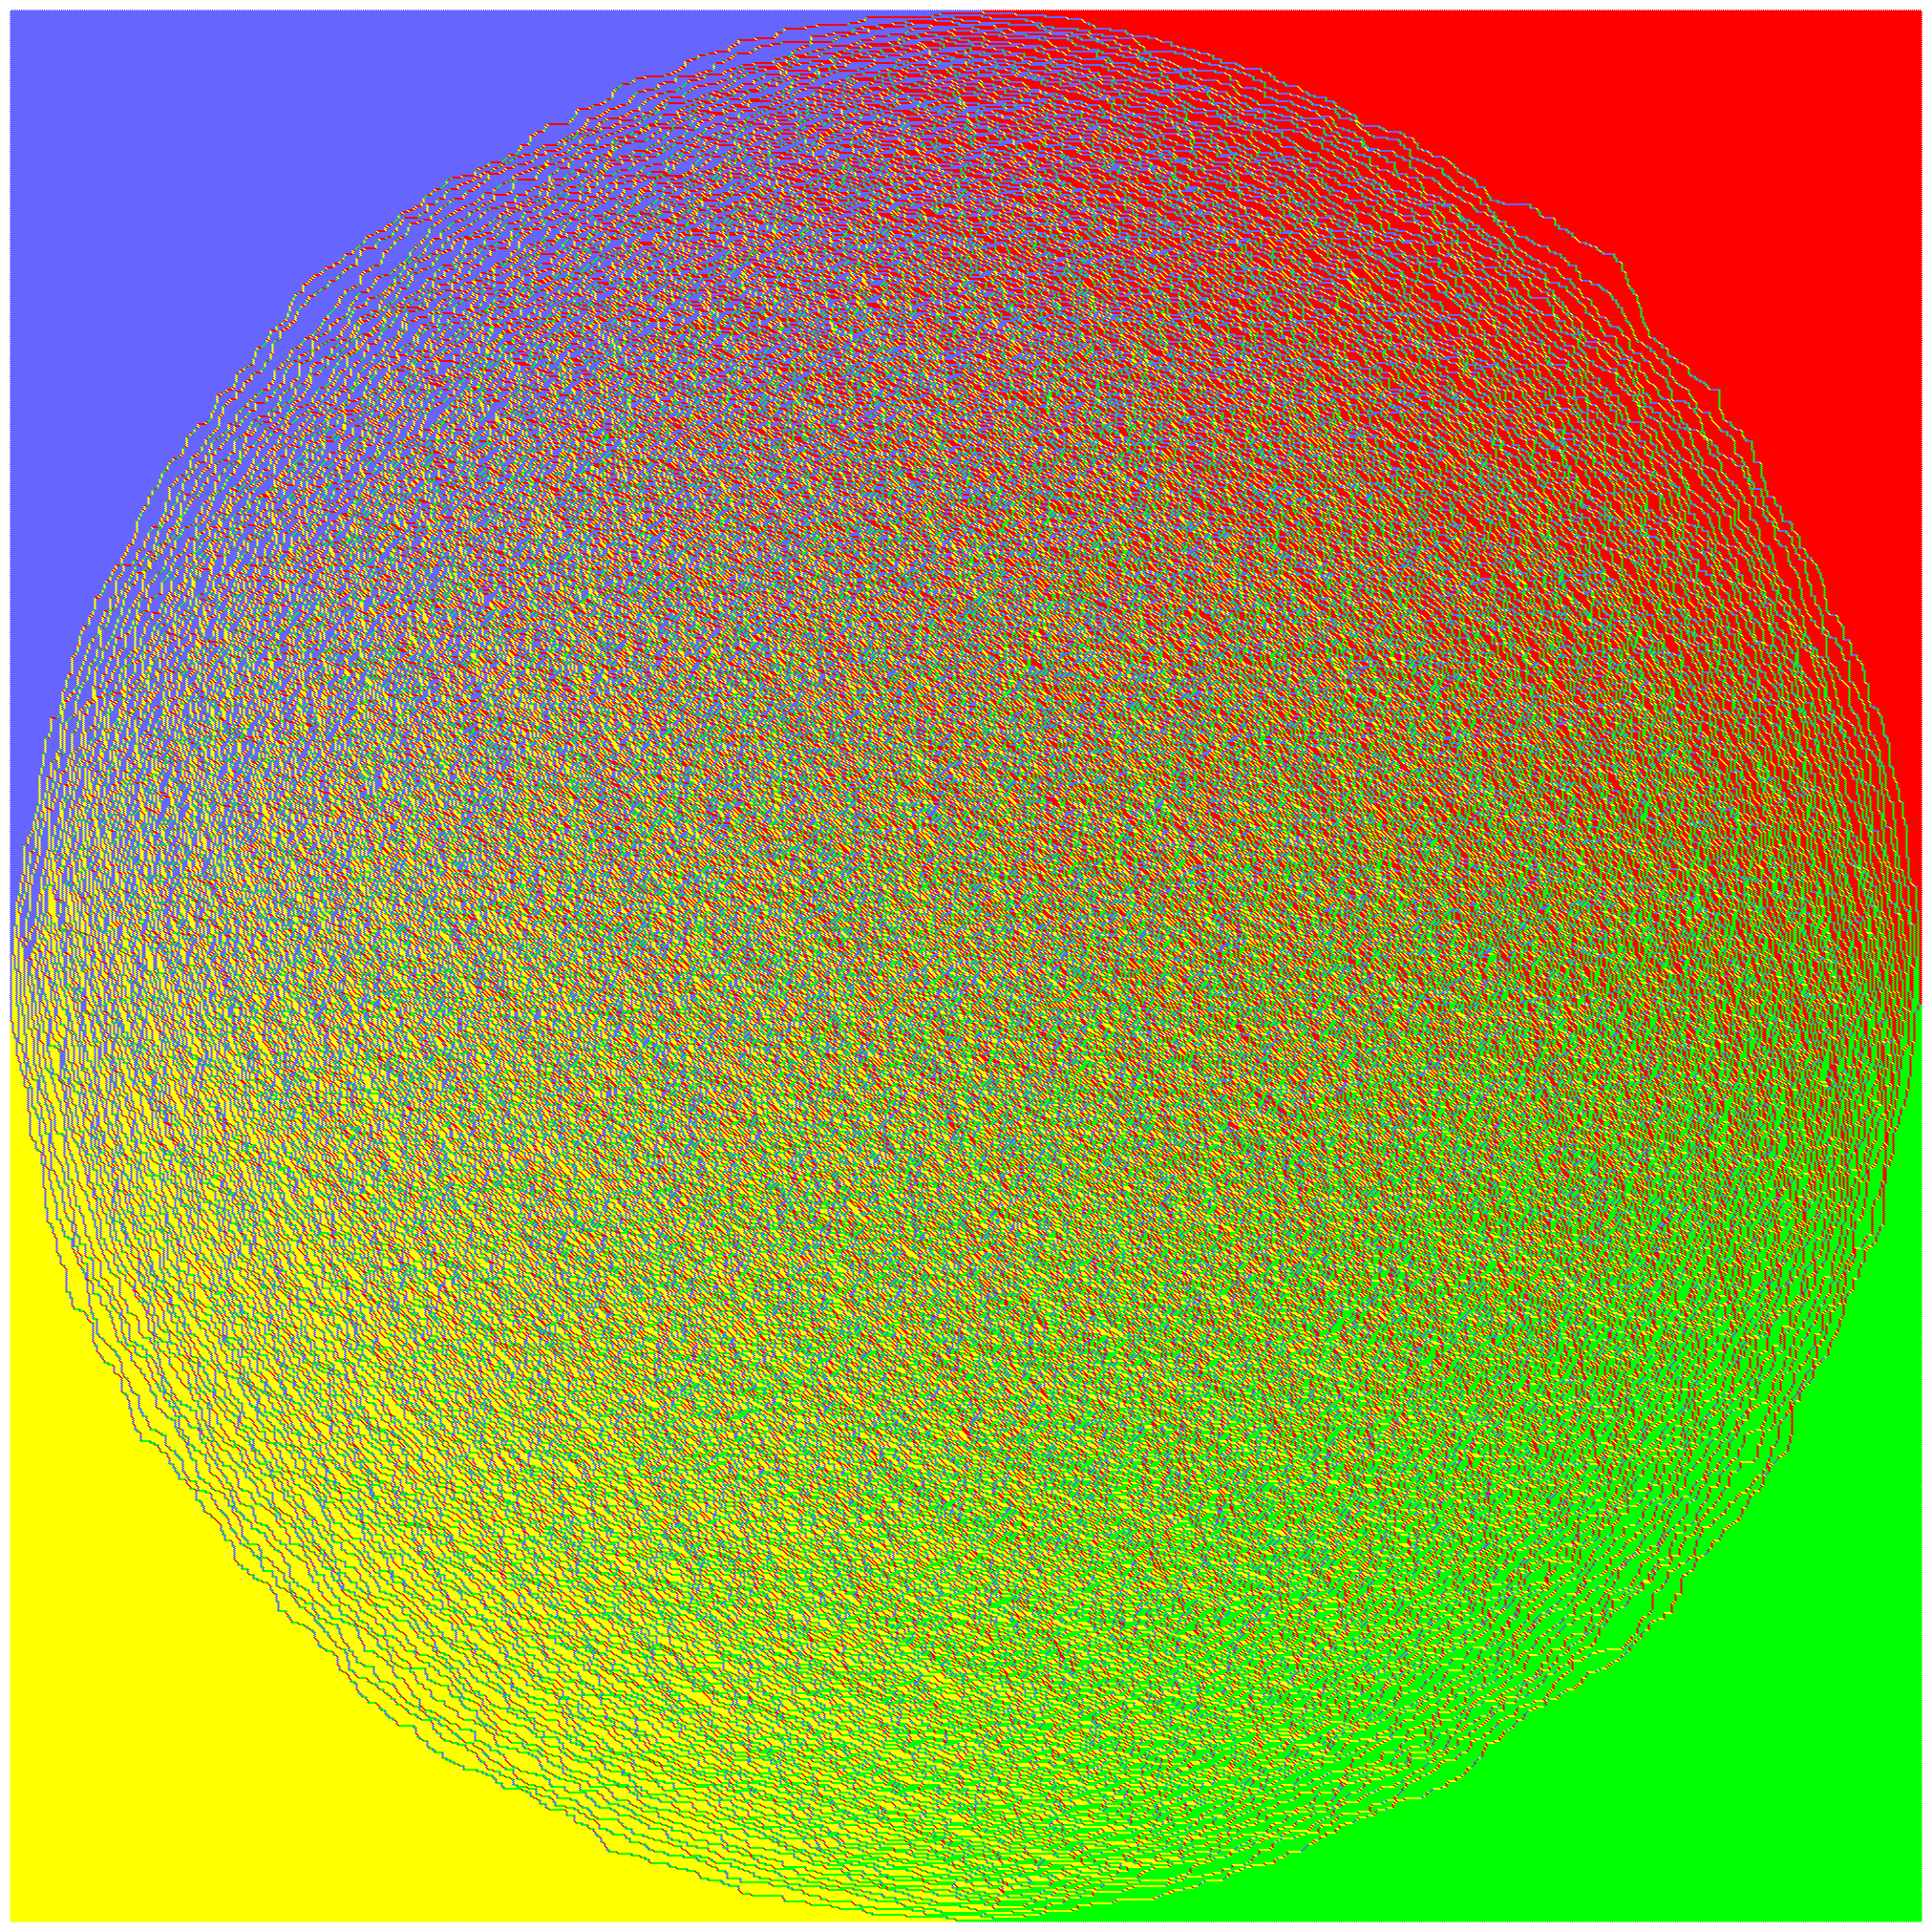

In [ ]:
dpi = 100
fig, ax = plt.subplots(dpi=dpi)


t1 = perf_counter()
img = compute_diamond_img(M)
print(perf_counter()-t1)

scale = oversampling_for_matplotlib_45(
    img,
    ax=ax,
    bg=0,
    crop=True,
    safety=1.1
)
#fig, ax = plt.subplots()

print('scale\t', scale)
scale = 1

Color = np.array([[1,1,1],[1,0,0],[0,1,0],[1,1,0],[0.4,0.4,1]])

t1 = perf_counter()
img_rot = rotate_labels_45(img,scale,0)
img_rot = Color[img_rot.T]
print(perf_counter()-t1)

plt.close(fig)

t1 = perf_counter()
H, W = img_rot.shape[:2]

fig = plt.figure(figsize=(W / dpi, H / dpi), dpi=dpi)
ax = fig.add_axes([0, 0, 1, 1])  # axes fills the whole figure

ax.imshow(img_rot, interpolation="nearest")
ax.axis("off")
fig.savefig('test.png',dpi = dpi)

print(perf_counter()-t1)


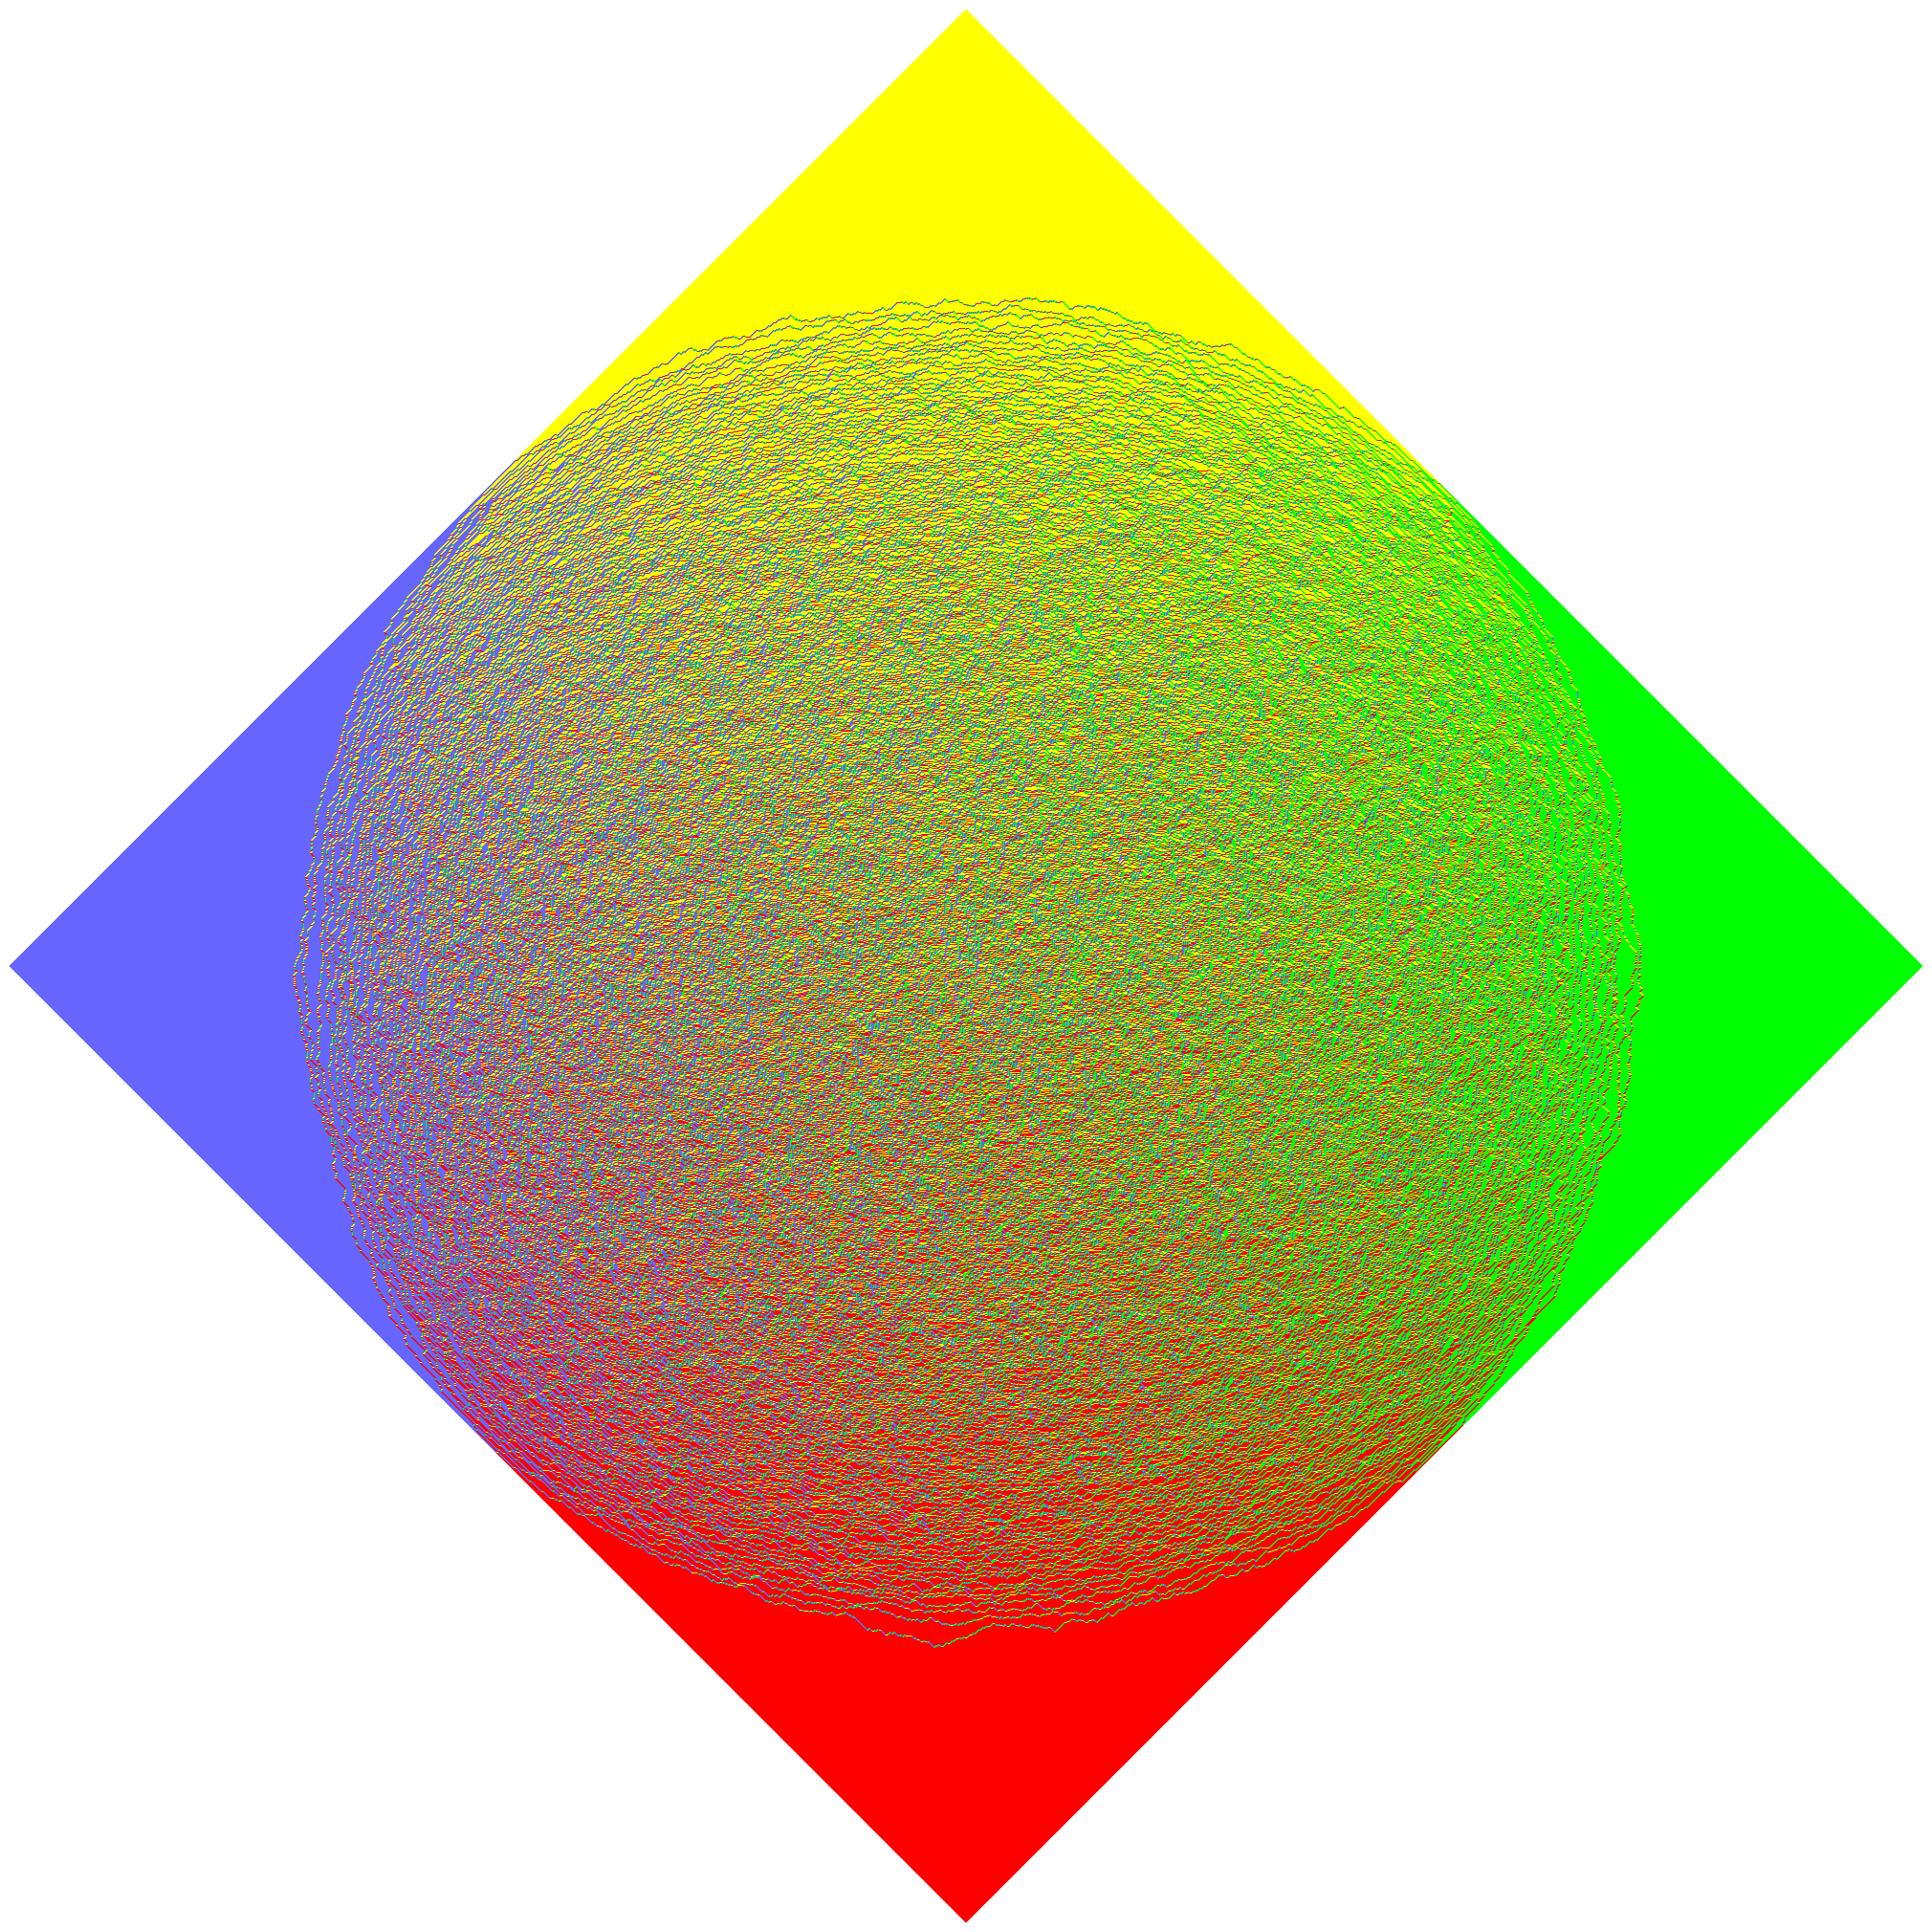

In [45]:
dpi = 100
Color = np.array([[1,1,1],[1,0,0],[0,1,0],[1,1,0],[0.4,0.4,1]])
img = compute_diamond_img(M)
img = Color[img]


H, W = img.shape[:2]

fig = plt.figure(figsize=(W / dpi, H / dpi), dpi=dpi)
ax = fig.add_axes([0, 0, 1, 1])  # axes fills the whole figure

ax.imshow(img, interpolation="nearest")
ax.axis("off")
fig.savefig('test0.png',dpi = dpi)

In [14]:
print(np.round(img.nbytes / 1024**2,3), "MB")
print(np.round(img_rot.nbytes / 1024**2,3), "MB")

3.815 MB
91.828 MB


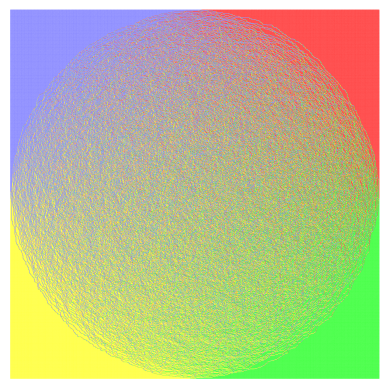

In [17]:
A.plot(dpi = 100,rotated=0)

In [20]:
fig = A.fig
fig.savefig('test.svg',dpi=100)

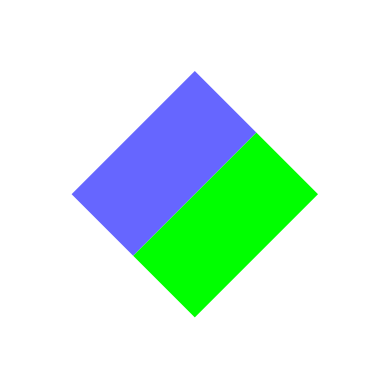

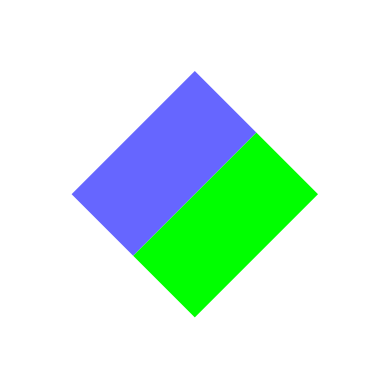

In [587]:
fast_plot(M,orientation='square')

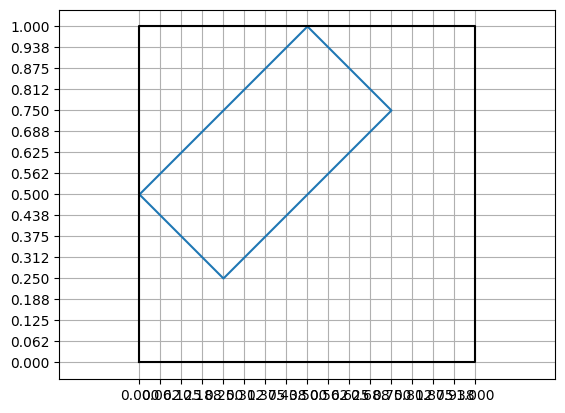

In [646]:
k = 15
plt.plot([0,0.5,0.75,0.25,0],[0.5,1,0.75,0.25,0.5])
plt.plot([0,0,1,1,0],[0,1,1,0,0],c = 'k')
plt.xticks(np.linspace(0,1,k+2))
plt.yticks(np.linspace(0,1,k+2))
plt.xlim(0,1)
plt.ylim(0,1)
plt.axis('equal')
plt.grid()

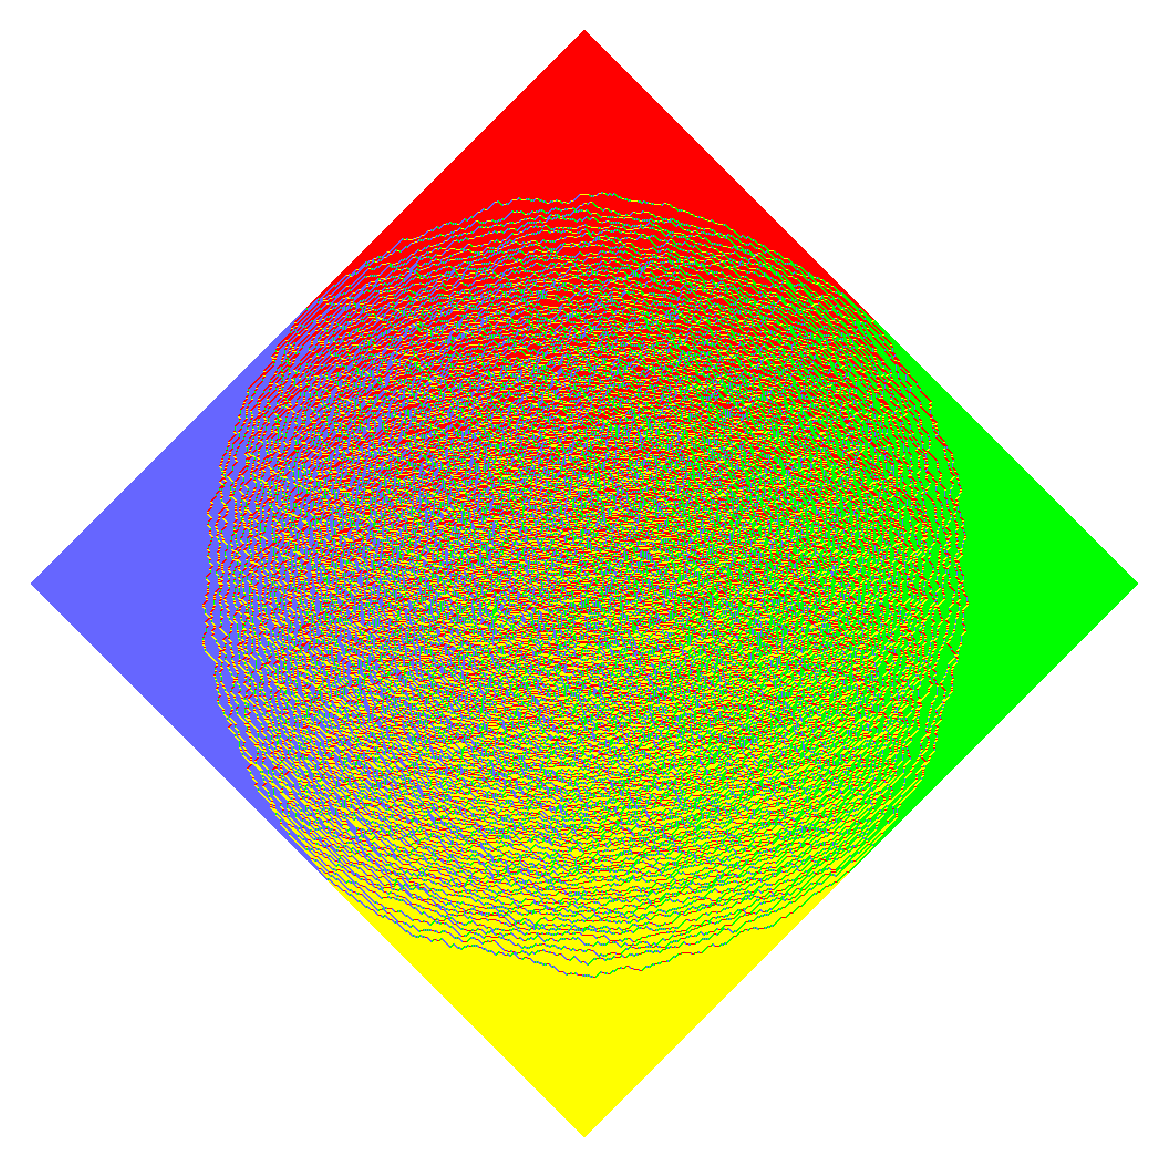

In [573]:
A.plot(dpi=300)

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import math


def get_axes_pixel_size(ax):
    """
    Return the size of an existing Matplotlib Axes in pixels.
    """
    fig = ax.figure
    fig.canvas.draw()  # make sure layout is computed
    bbox = ax.get_window_extent()
    return int(round(bbox.width)), int(round(bbox.height))


def rotated45_base_shape(A, bg=0, crop=True):
    """
    Compute the approximate output shape of the 45-degree label renderer
    at scale=1.

    This matches the coordinate convention

        u = j - i
        v = j + i

    used in rotate_labels_45_numba.
    """
    A = np.asarray(A)

    if crop:
        ii, jj = np.nonzero(A != bg)

        if len(ii) == 0:
            return 1, 1

        u = jj - ii
        v = jj + ii

        u_span = u.max() - u.min()
        v_span = v.max() - v.min()
    else:
        h, w = A.shape[:2]
        u_span = (w - 1) + (h - 1)
        v_span = (w - 1) + (h - 1)

    # For the diamond renderer:
    # W(scale) ≈ (u_span + 2) * scale
    # H(scale) ≈ (v_span + 2) * scale
    base_w = u_span + 2
    base_h = v_span + 2

    return base_h, base_w


def oversampling_for_matplotlib_45(A, ax, bg=0, crop=True, safety=1.0):
    """
    Choose scale so that the rotated image has at least as many pixels
    as the Matplotlib axes.

    Parameters
    ----------
    A:
        Label matrix.

    ax:
        Matplotlib axes into which the image will be plotted.

    bg:
        Background label, usually 0.

    crop:
        If True, compute the size only from non-background pixels.

    safety:
        Extra factor. Use 1.0 normally, 1.2 or 1.5 for slightly more resolution.

    Returns
    -------
    scale : int
    """
    target_w_px, target_h_px = get_axes_pixel_size(ax)
    base_h, base_w = rotated45_base_shape(A, bg=bg, crop=crop)

    scale_w = target_w_px / base_w
    scale_h = target_h_px / base_h

    scale = math.ceil(safety * max(scale_w, scale_h))

    return max(1, scale)

chosen scale: 164


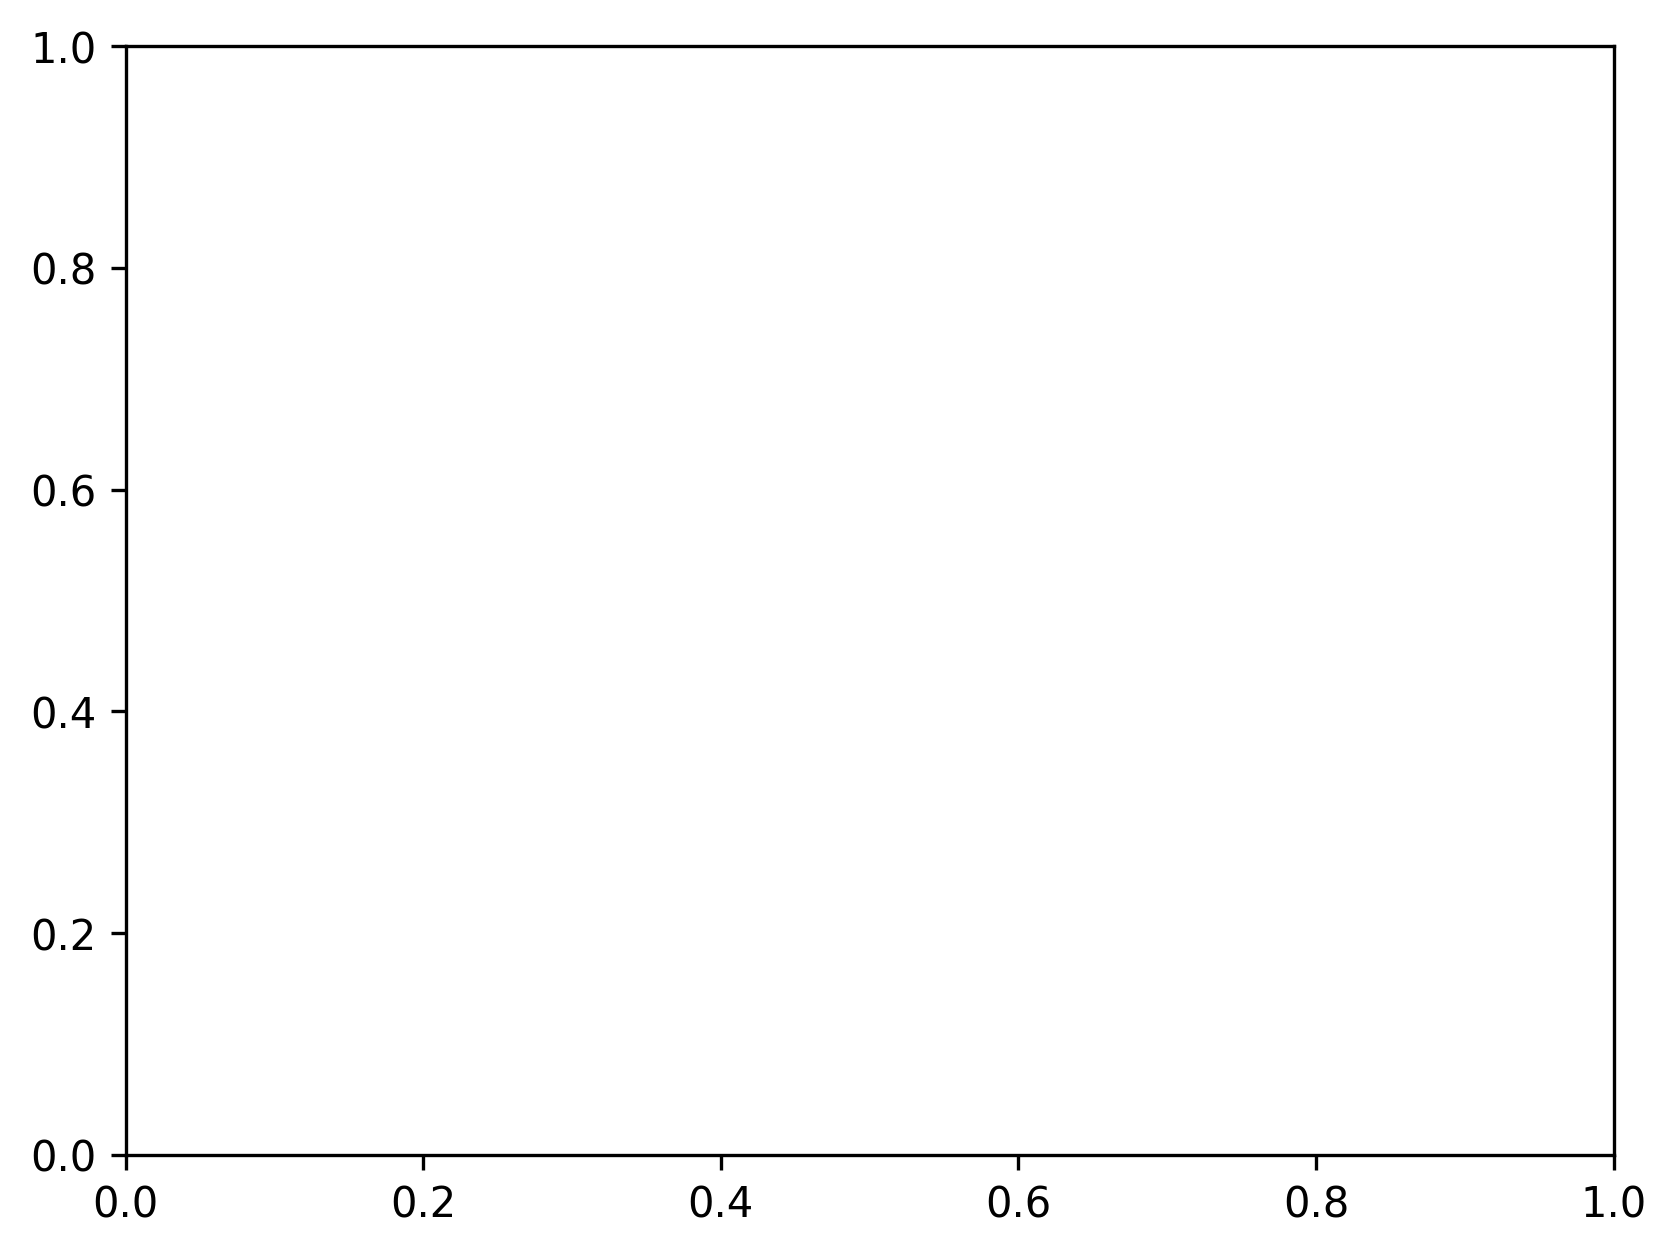

In [540]:
fig, ax = plt.subplots(dpi=300)

scale = oversampling_for_matplotlib_45(
    img,
    ax=ax,
    bg=0,
    crop=True,
    safety=1.1
)

print("chosen scale:", scale)

0.09054509998532012


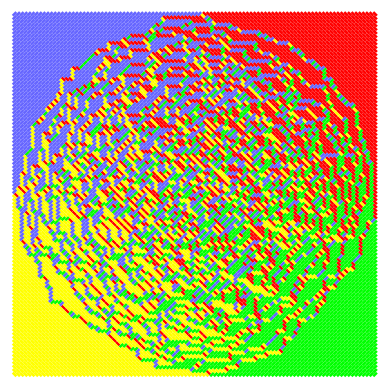

In [523]:
t1 = perf_counter()
A.plot(rotated = 0)
print(perf_counter()-t1)

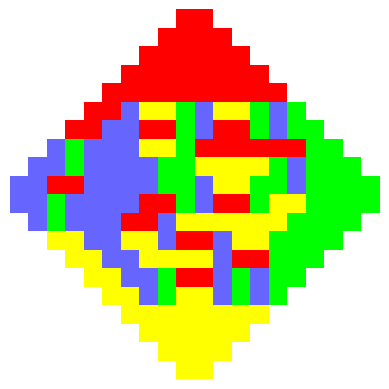

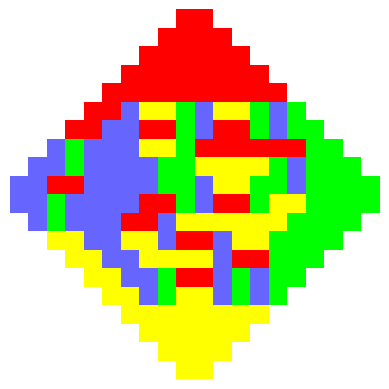

In [415]:
diamond_img(M)

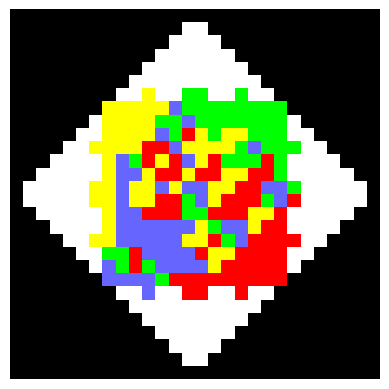

In [414]:
plt.imshow(img_rot, interpolation="nearest")
plt.axis("off")
plt.show()

0.11565370002062991


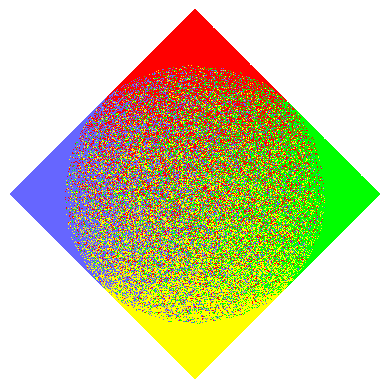

In [396]:
t1 = perf_counter()
diamond_img(M)
print(perf_counter()-t1)

# Time Compare

In [139]:
# Diasable automatic plotting
%matplotlib agg

# Get back to normal
#%matplotlib inline

In [1060]:
%matplotlib agg
from tqdm import trange

N    = trange(50,1050,50)
reps = 5
T1   = []
T2   = []
T3   = []


dpi = 100
w = np.array([[1]])
for n in N:
    A = RT.Aztec(n,w)
    A.shuffle()
    M = A.get_M()
    tmpT1 = []
    tmpT2 = []
    tmpT3 = []
    for _ in range(reps):
        # garbage collection
        collect()
        t1 = time()
        A.plot(rotated=1,dpi=dpi,show_figure=False)
        tmpT1 += [time()-t1]
        fig = A.fig
        plt.close(fig)
        del fig


        # garbage collection
        collect()
        t1 = time()
        fig = fast_plot(M)
        tmpT2 += [time()-t1]
        plt.close(fig)
        del fig


        # garbage collection
        collect()
        t1 = time()
        fig = draw_dominos0(M)
        tmpT3 += [time()-t1]
        plt.close(fig)
        del fig

    T1 += [tmpT1]
    T2 += [tmpT2]
    T3 += [tmpT3]



T1 = np.array(T1)
T2 = np.array(T2)
T3 = np.array(T3)        


100%|██████████| 20/20 [16:15<00:00, 48.76s/it]


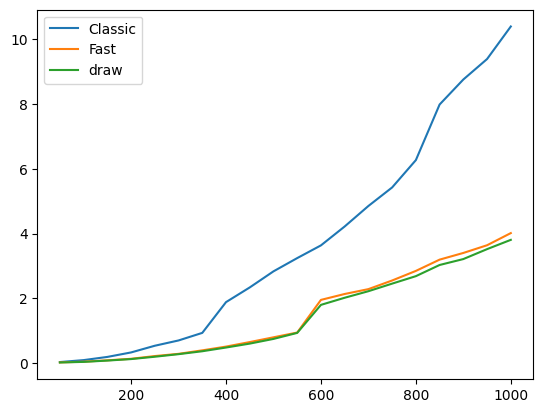

In [1061]:
%matplotlib inline
plt.plot(range(50,50*(len(T1)+1),50),np.median(T1,1),label='Classic')
plt.plot(range(50,50*(len(T2)+1),50),np.median(T2,1),label = 'Fast')
plt.plot(range(50,50*(len(T3)+1),50),np.median(T3,1),label = 'draw')
plt.legend()
plt.show()

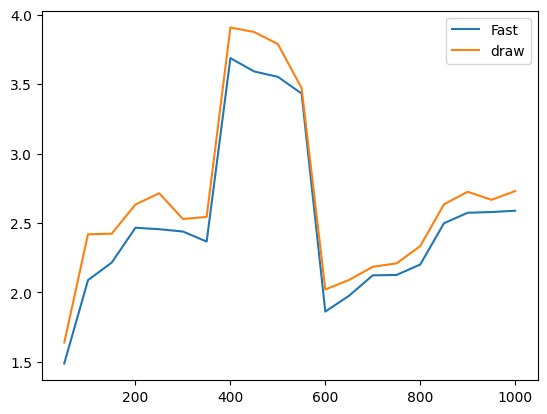

In [1062]:

plt.plot(range(50,50*(len(T2)+1),50),np.median(T1,1)/np.median(T2,1),label = 'Fast')
plt.plot(range(50,50*(len(T3)+1),50),np.median(T1,1)/np.median(T3,1),label = 'draw')
plt.legend()
plt.show()

In [1047]:
n = 200
reps = 40

A = RT.Aztec(n,w)
A.shuffle()
M = A.get_M()


tmpT1 = []
tmpT2 = []
REPS = np.arange(reps)
%matplotlib agg
for _ in tqdm(REPS):
    # garbage collection
    collect()
    
    t1 = perf_counter()
    A.plot(rotated=False,dpi=dpi,show_figure=False)
    tmpT1 += [perf_counter()-t1]
    fig = A.fig
    plt.close(fig)
    del fig
    
    # garbage collection
    collect()

    t1 = perf_counter()
    fig = draw_dominos0(M)
    tmpT2 += [perf_counter()-t1]
    plt.close(fig)
    del fig

tmpT1 = np.array(tmpT1)
tmpT2 = np.array(tmpT2)

100%|██████████| 40/40 [01:18<00:00,  1.97s/it]


In [1048]:
print('Mean    \t',tmpT1.mean()/tmpT2.mean())
print('Median  \t',np.median(tmpT1)/np.median(tmpT2))
print()
print('Best    \t',tmpT1.min()/tmpT2.min())
print('Worst   \t',tmpT1.max()/tmpT2.max())
print()
print('Std     \t',(tmpT1/tmpT2).std())
print('Rel Std \t',(tmpT1/tmpT2).std()/(tmpT1/tmpT2).mean())

Mean    	 2.4375219158125874
Median  	 2.5175910714469607

Best    	 2.5169322269337004
Worst   	 2.1107177709225557

Std     	 0.4262671062756917
Rel Std 	 0.17059575333171192


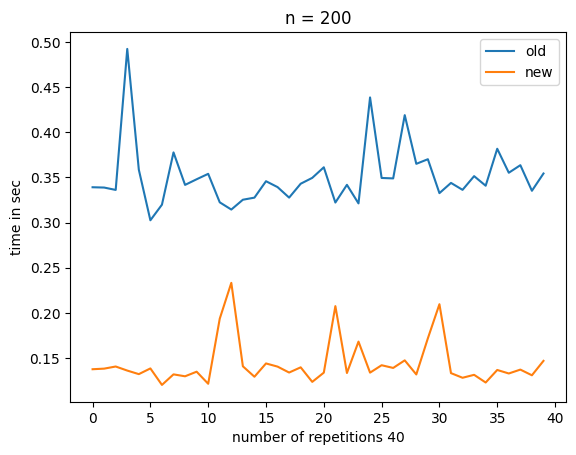

In [1049]:
%matplotlib inline
fig = plt.Figure()
plt.title('n = '+str(n))
plt.ylabel('time in sec')
plt.xlabel('number of repetitions '+str(reps))
plt.plot(REPS,tmpT1,label='old')
plt.plot(REPS,tmpT2,label='new')
plt.legend()
plt.show()

In [ ]:
len(M)

1000

In [ ]:
t1  = time()
P,C = compute_domino_data(M)
Color = np.array([[1,0,0],[0,1,0],[1,1,0],[0.4,0.4,1]])

margin = 1
fig, ax = plt.subplots(dpi = dpi)

ax.set_xlim(-0.5-margin,len(M)+1.5+margin)
ax.set_ylim(-0.5-margin,len(M)+1.5+margin)

Color = np.array([[1,0,0],[0,1,0],[1,1,0],[0.4,0.4,1]])

ax.add_collection(PolyCollection(P,facecolor=Color[C]))
ax.set_aspect('equal')
ax.axis('off')
print(time() - t1)


0.5720810890197754
